<a href="https://colab.research.google.com/github/sriharshitha06/Machine-Learning/blob/main/covid_19_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import pandas as pd

# Path to the zip file
zip_file_path = '/content/covid_19_data.csv.zip'

# Extract the CSV file from the zip archive
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extract('covid_19_data.csv', '/content/') # Extract to /content/

# Load the extracted CSV into a pandas DataFrame
df_covid = pd.read_csv('/content/covid_19_data.csv')

# Display the first few rows of the DataFrame
print('DataFrame loaded successfully. First 5 rows:')
print(df_covid.head())

DataFrame loaded successfully. First 5 rows:
   SNo ObservationDate Province/State  Country/Region      Last Update  \
0    1      01/22/2020          Anhui  Mainland China  1/22/2020 17:00   
1    2      01/22/2020        Beijing  Mainland China  1/22/2020 17:00   
2    3      01/22/2020      Chongqing  Mainland China  1/22/2020 17:00   
3    4      01/22/2020         Fujian  Mainland China  1/22/2020 17:00   
4    5      01/22/2020          Gansu  Mainland China  1/22/2020 17:00   

   Confirmed  Deaths  Recovered  
0        1.0     0.0        0.0  
1       14.0     0.0        0.0  
2        6.0     0.0        0.0  
3        1.0     0.0        0.0  
4        0.0     0.0        0.0  


In [2]:
print("Displaying the first 5 rows of the DataFrame:")
print(df_covid.head())

print("\nDataFrame Information:")
df_covid.info()

print("\nMissing Values per Column:")
print(df_covid.isnull().sum())

# Convert 'ObservationDate' to datetime objects
df_covid['ObservationDate'] = pd.to_datetime(df_covid['ObservationDate'])

print("\n'ObservationDate' column converted to datetime type. Verifying info again:")
df_covid.info()

Displaying the first 5 rows of the DataFrame:
   SNo ObservationDate Province/State  Country/Region      Last Update  \
0    1      01/22/2020          Anhui  Mainland China  1/22/2020 17:00   
1    2      01/22/2020        Beijing  Mainland China  1/22/2020 17:00   
2    3      01/22/2020      Chongqing  Mainland China  1/22/2020 17:00   
3    4      01/22/2020         Fujian  Mainland China  1/22/2020 17:00   
4    5      01/22/2020          Gansu  Mainland China  1/22/2020 17:00   

   Confirmed  Deaths  Recovered  
0        1.0     0.0        0.0  
1       14.0     0.0        0.0  
2        6.0     0.0        0.0  
3        1.0     0.0        0.0  
4        0.0     0.0        0.0  

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306429 entries, 0 to 306428
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   SNo              306429 non-null  int64  
 1   ObservationDate  306429 n

In [3]:
df_global_trends = df_covid.groupby('ObservationDate')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

# Calculate daily new confirmed cases, deaths, and recoveries
df_global_trends['Daily_Confirmed'] = df_global_trends['Confirmed'].diff().fillna(0)
df_global_trends['Daily_Deaths'] = df_global_trends['Deaths'].diff().fillna(0)
df_global_trends['Daily_Recovered'] = df_global_trends['Recovered'].diff().fillna(0)

# Ensure daily new values are not negative (can happen if data correction occurs)
df_global_trends['Daily_Confirmed'] = df_global_trends['Daily_Confirmed'].apply(lambda x: max(0, x))
df_global_trends['Daily_Deaths'] = df_global_trends['Daily_Deaths'].apply(lambda x: max(0, x))
df_global_trends['Daily_Recovered'] = df_global_trends['Daily_Recovered'].apply(lambda x: max(0, x))

print("Global daily and cumulative trends calculated successfully. First 5 rows:")
print(df_global_trends.head())

Global daily and cumulative trends calculated successfully. First 5 rows:
  ObservationDate  Confirmed  Deaths  Recovered  Daily_Confirmed  \
0      2020-01-22      557.0    17.0       30.0              0.0   
1      2020-01-23     1097.0    34.0       60.0            540.0   
2      2020-01-24      941.0    26.0       39.0              0.0   
3      2020-01-25     1437.0    42.0       42.0            496.0   
4      2020-01-26     2118.0    56.0       56.0            681.0   

   Daily_Deaths  Daily_Recovered  
0           0.0              0.0  
1          17.0             30.0  
2           0.0              0.0  
3          16.0              3.0  
4          14.0             14.0  


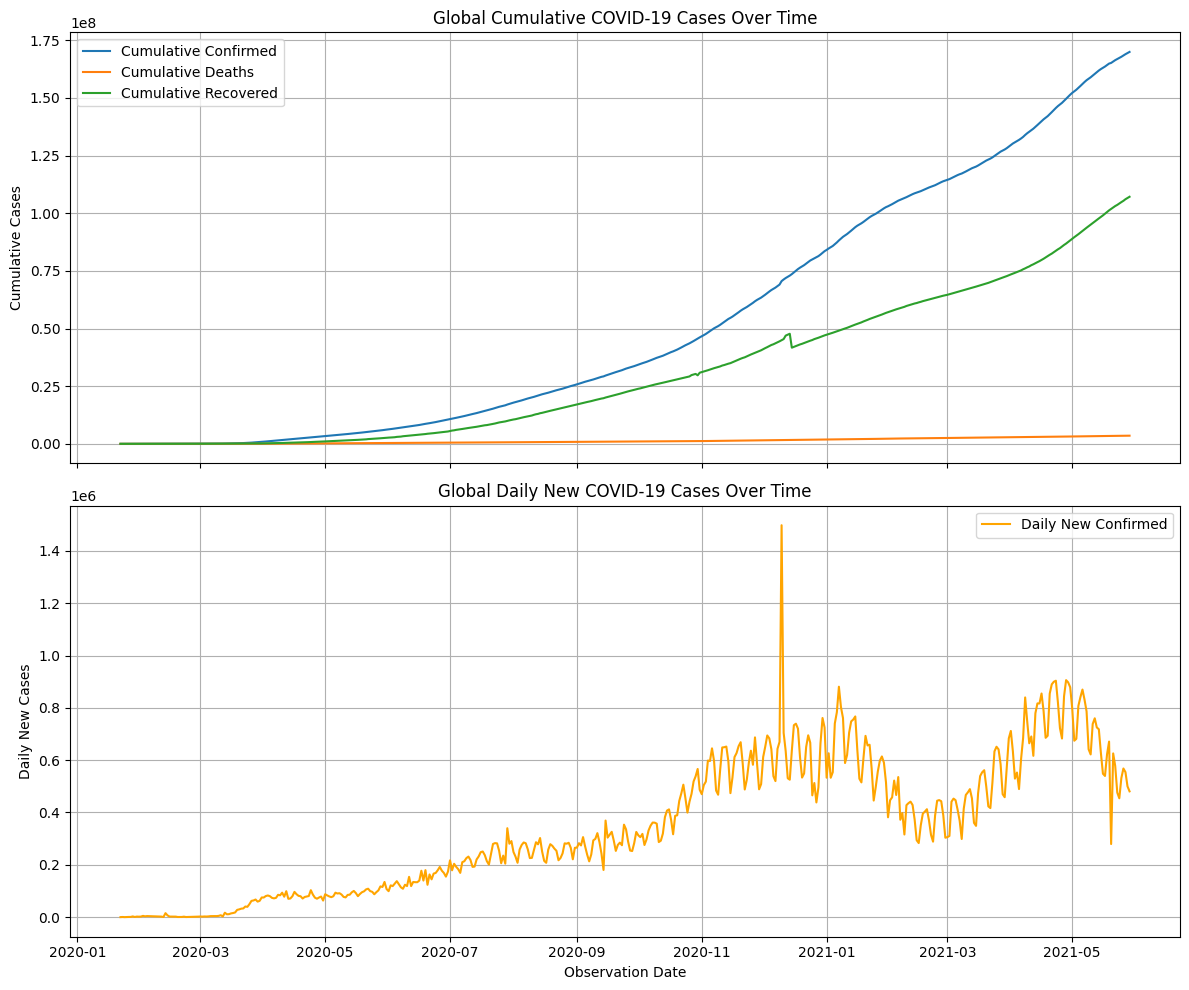

In [4]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

# Plotting Global Cumulative Trends
axes[0].plot(df_global_trends['ObservationDate'], df_global_trends['Confirmed'], label='Cumulative Confirmed')
axes[0].plot(df_global_trends['ObservationDate'], df_global_trends['Deaths'], label='Cumulative Deaths')
axes[0].plot(df_global_trends['ObservationDate'], df_global_trends['Recovered'], label='Cumulative Recovered')
axes[0].set_ylabel('Cumulative Cases')
axes[0].set_title('Global Cumulative COVID-19 Cases Over Time')
axes[0].legend()
axes[0].grid(True)

# Plotting Global Daily New Cases
axes[1].plot(df_global_trends['ObservationDate'], df_global_trends['Daily_Confirmed'], label='Daily New Confirmed', color='orange')
axes[1].set_ylabel('Daily New Cases')
axes[1].set_title('Global Daily New COVID-19 Cases Over Time')
axes[1].legend()
axes[1].grid(True)

# Common x-axis label
plt.xlabel('Observation Date')

# Ensure plots are well-spaced
plt.tight_layout()
plt.show()

Top 10 Countries by Confirmed COVID-19 Cases on 2021-05-29:
    Country/Region   Confirmed    Deaths   Recovered
182             US  33251939.0  594306.0         0.0
78           India  27894800.0  325972.0  25454320.0
23          Brazil  16471600.0  461057.0  14496224.0
60          France   5719877.0  109518.0    390878.0
180         Turkey   5235978.0   47271.0   5094279.0
144         Russia   4995613.0  118781.0   4616422.0
181             UK   4496823.0  128037.0     15481.0
84           Italy   4213055.0  126002.0   3845087.0
6        Argentina   3732263.0   77108.0   3288467.0
64         Germany   3684672.0   88413.0   3479700.0


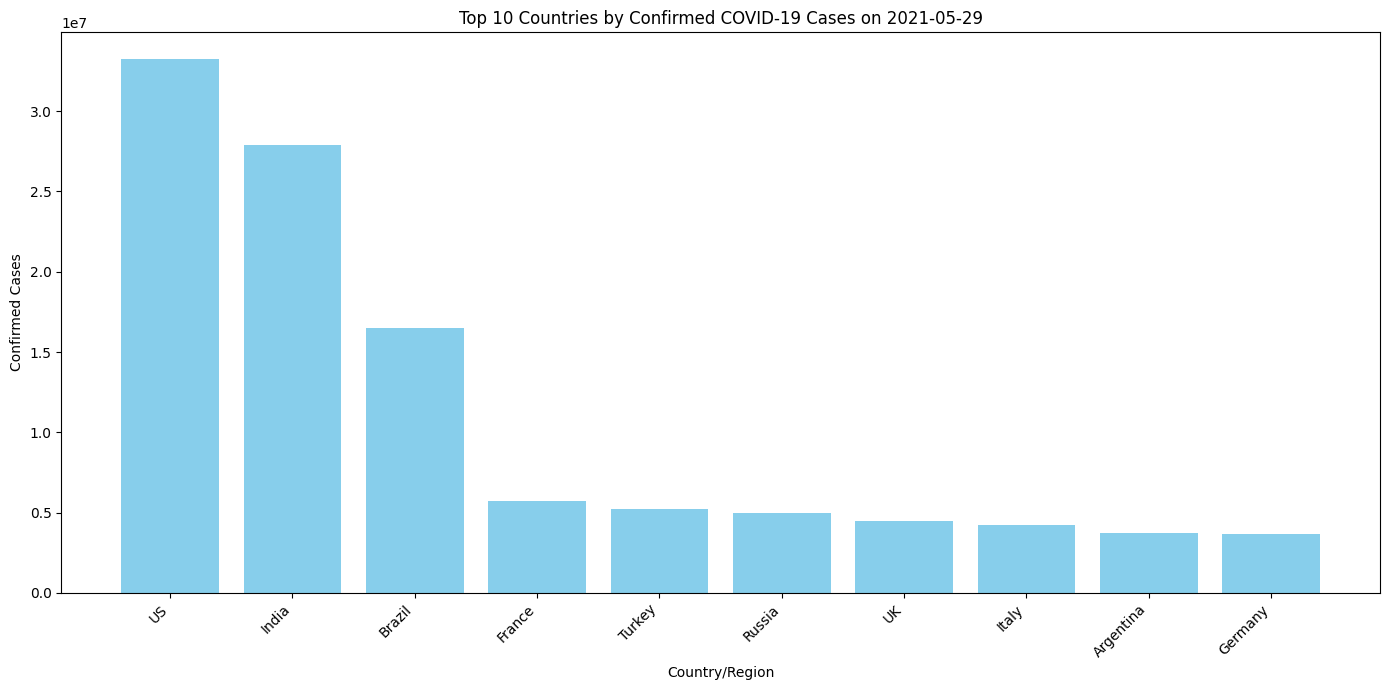

In [5]:
latest_date = df_covid['ObservationDate'].max()
df_latest_date = df_covid[df_covid['ObservationDate'] == latest_date]

top_countries = df_latest_date.groupby('Country/Region')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()
top_countries = top_countries.sort_values(by='Confirmed', ascending=False).head(10)

print(f"Top 10 Countries by Confirmed COVID-19 Cases on {latest_date.strftime('%Y-%m-%d')}:")
print(top_countries)

# Visualize the top 10 countries
plt.figure(figsize=(14, 7))
plt.bar(top_countries['Country/Region'], top_countries['Confirmed'], color='skyblue')
plt.xlabel('Country/Region')
plt.ylabel('Confirmed Cases')
plt.title(f'Top 10 Countries by Confirmed COVID-19 Cases on {latest_date.strftime('%Y-%m-%d')}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
selected_countries = top_countries['Country/Region'].head(5).tolist()
print(f"Selected Top 5 Countries: {selected_countries}")

df_top_countries_time_series = df_covid[df_covid['Country/Region'].isin(selected_countries)]

# Group by ObservationDate and Country/Region and sum Confirmed cases
df_top_countries_time_series_agg = df_top_countries_time_series.groupby(['ObservationDate', 'Country/Region'])['Confirmed'].sum().reset_index()

print("Aggregated data for top countries' time series. First 5 rows:")
print(df_top_countries_time_series_agg.head())

Selected Top 5 Countries: ['US', 'India', 'Brazil', 'France', 'Turkey']
Aggregated data for top countries' time series. First 5 rows:
  ObservationDate Country/Region  Confirmed
0      2020-01-22             US        1.0
1      2020-01-23         Brazil        0.0
2      2020-01-23             US        1.0
3      2020-01-24         France        2.0
4      2020-01-24             US        2.0


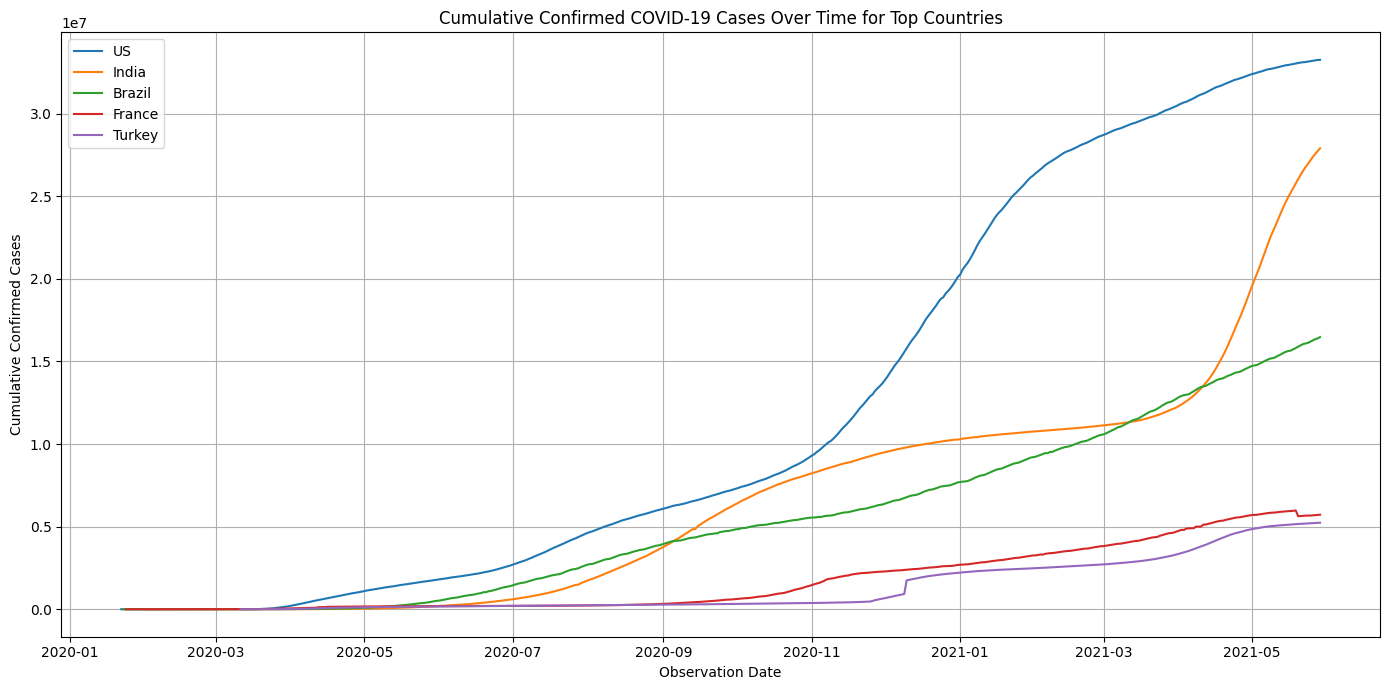

In [7]:
plt.figure(figsize=(14, 7))

for country in selected_countries:
    country_data = df_top_countries_time_series_agg[df_top_countries_time_series_agg['Country/Region'] == country]
    plt.plot(country_data['ObservationDate'], country_data['Confirmed'], label=country)

plt.title('Cumulative Confirmed COVID-19 Cases Over Time for Top Countries')
plt.xlabel('Observation Date')
plt.ylabel('Cumulative Confirmed Cases')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()